In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append(r'../') # Add this line at the beginner of each notebook to be able to load local functions 
import src.features.EL_data as eld
import src.set_paths as sps

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import warnings
import cftime

In [3]:
def load_el_data(csv_path, csv_file, instr, year):
    ladcp_list = eld.get_bodc_files_from_metadata(csv_path, csv_file, instr, year)
    
    # --- Combine all files using open_mfdataset ---
    if instr == 'ladcp':
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=UserWarning)
            
            ds = xr.open_mfdataset(
                ladcp_list,
                preprocess=eld.preprocess_ladcp_file,
                combine='nested',          # Use nested combination
                concat_dim='INSTANCE',     # Concatenate along the single 'INSTANCE' dimension
                join='outer',              # Use 'outer' join for the varying 'MAXZ' dimension
                decode_times=True,         # We handle time decoding manually in preprocess
                data_vars='all'
            )
    return ds

In [29]:
# Location of EEL stations in RT
pathdir_EEL = sps.one_drive_data_dir/'data_RT_EEL_cruises/EEL_LOIC/csv_ctdgrid'
file_EEL = pathdir_EEL/'EELCTDandLADCP_refpos.csv'

dfs = eld.load_EEL_stations(file_EEL,RT_only=True)
dfs

<xarray.Dataset> Size: 800B
Dimensions:   (refdist: 20)
Coordinates:
  * refdist   (refdist) int64 160B 837 855 875 883 897 ... 1105 1111 1125 1140
Data variables:
    Staname   (refdist) object 160B 'A' 'B' 'C' 'D' 'E' ... 'P' 'Q1' 'Q' 'R' 'S'
    LonSta    (refdist) float64 160B -13.63 -13.33 -13.0 ... -9.217 -9.0 -8.783
    LatSta    (refdist) float64 160B 57.58 57.57 57.55 ... 57.05 57.0 56.95
    DepthSta  (refdist) int64 160B 100 200 330 1000 1650 ... 800 500 300 125

In [ ]:
csv_path = 'C:/Users/sa07kb/Projects/Rockall_Trough_Transports/data/raw/UK_OSNAP/'
csv_file = 'bodc_series_metadata_summary.csv'
instr = 'ctd'
year = 2018

if instr == 'ladcp':
    instrument = 'Acoustic doppler current profiler'
    platform = 'research vessel'
    positional_definition = 'Fixed point'
elif instr == 'vmadcp':
    instrument = 'Acoustic doppler current profiler'
    platform = 'research vessel'
    positional_definition = 'Line trajectory'
elif instr == 'ctd':
    instrument = 'CTD/STD cast'
    platform = 'research vessel'
    positional_definition = 'Fixed point'

df = pd.read_csv(csv_path+csv_file, header=23)
df_filtered = df[df['Instrument'].str.contains(instrument, case=False, na=False)]
df_filtered['Start date'] = pd.to_datetime(df_filtered['Start date'], format='%d/%m/%Y')
df_filtered['Start date'].dt.year.unique()

In [43]:
csv_path = 'C:/Users/sa07kb/Projects/Rockall_Trough_Transports/data/raw/UK_OSNAP/'
csv_file = 'bodc_series_metadata_summary.csv'
instr = 'ladcp'
year = 2022
ds = load_el_data(csv_path, csv_file, instr, year)
ds

<xarray.Dataset> Size: 789kB
Dimensions:                 (INSTANCE: 43, REFMAX: 5, MAXZ: 375, TIME: 43)
Coordinates:
  * TIME                    (TIME) datetime64[ns] 344B 2022-07-01T21:12:18.00...
  * MAXZ                    (MAXZ) int64 3kB 1 2 3 4 5 6 ... 371 372 373 374 375
    LATITUDE                (INSTANCE) float64 344B dask.array<chunksize=(1,), meta=np.ndarray>
    LONGITUDE               (INSTANCE) float64 344B dask.array<chunksize=(1,), meta=np.ndarray>
    DEPTH                   (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
Dimensions without coordinates: INSTANCE, REFMAX
Data variables: (12/18)
    SDN_CRUISE              (INSTANCE) |S80 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    crs                     (INSTANCE) int32 172B 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
    SDN_EDMO_CODE           (INSTANCE) int32 172B dask.array<chunksize=(1,), meta=np.ndarray>
    SDN_STATION             (INSTANCE) |S80 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    SDN_LOCAL_CDI_ID        (INSTANCE) |S80 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    SDN_XLINK               (INSTANCE, REFMAX) |S299 64kB dask.array<chunksize=(1, 5), meta=np.ndarray>
    ...                      ...
    ERRVLDCP_SEADATANET_QC  (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
    ERRVLDCP                (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
    LCEWLW01_SEADATANET_QC  (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
    LCEWLW01                (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
    LCNSLW01_SEADATANET_QC  (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
    LCNSLW01                (INSTANCE, MAXZ) float32 64kB dask.array<chunksize=(1, 13), meta=np.ndarray>
Attributes:
    date_update:  2025-08-15T01:01:44+0100
    comment:      
    Conventions:  SeaDataNet_1.0 CF-1.6
    featureType:  profile
    title:        SeaDataNet NETCDF PROFILE Climate Forecast 1.6 - GENERATED ...

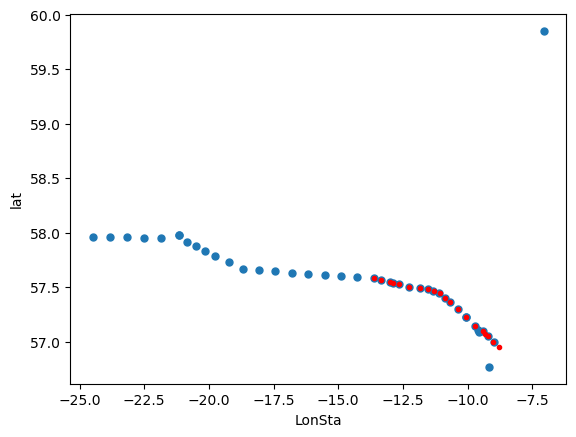

In [33]:
ds.LCNSLW01.LONGITUDE.plot.line('.',ms=10, y='LATITUDE')
dfs.LonSta.assign_coords(lat=dfs.LatSta).plot.line('.r',y='lat')

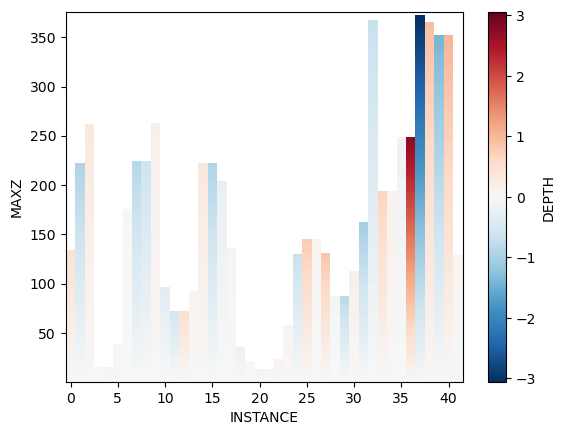

In [7]:
ds.DEPTH.diff('INSTANCE').plot(y='MAXZ')

In [ ]:
### test file for AR30-4
dirpath = 'C:/Users/sa07kb/Projects/Rockall_Trough_Transports/data/raw/'
file='ctd_ar304_007_2db.nc'

ds_ctd = xr.open_dataset(dirpath+file,decode_timedelta=False)

In [48]:
ds_ctd.depth.values

array([[  2.9724682 ,   4.95408963,   6.93569184,   8.91727482,
         10.89883858,  12.88038312,  14.86190844,  16.84341454,
         18.82490142,  20.80636909,  22.78781754,  24.76924677,
         26.75065679,  28.7320476 ,  30.71341919,  32.69477158,
         34.67610476,  36.65741872,  38.63871348,  40.61998904,
         42.60124539,  44.58248254,  46.56370048,  48.54489923,
         50.52607877,  52.50723911,  54.48838026,  56.46950221,
         58.45060496,  60.43168852,  62.41275289,  64.39379806,
         66.37482404,  68.35583083,  70.33681843,  72.31778685,
         74.29873608,  76.27966612,  78.26057698,  80.24146865,
         82.22234115,  84.20319446,  86.18402859,  88.16484354,
         90.14563932,  92.12641591,  94.10717334,  96.08791159,
         98.06863066, 100.04933056, 102.0300113 , 104.01067286,
        105.99131525, 107.97193848, 109.95254254, 111.93312743,
        113.91369316, 115.89423973, 117.87476713, 119.85527538,
        121.83576446, 123.81623439, 125.